# Weighted Conformal Prediction

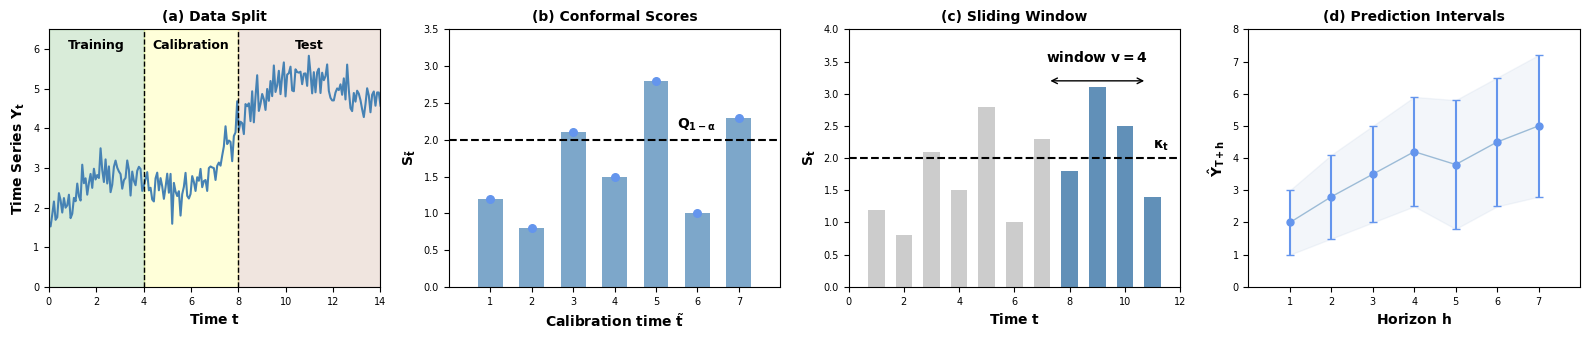

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))


# Data Split
ax1 = axes[0]
ax1.set_title(r'(a) Data Split', fontsize=10, fontweight='bold', loc='center')

np.random.seed(42)
t = np.linspace(0, 14, 200)
y = 1.5 + 0.3*t + 0.8*np.sin(0.8*t) + 0.3*np.random.randn(200)
y = np.clip(y, 0.5, 6.0)

ax1.plot(t, y, color='steelblue', linestyle='-', linewidth=1.5)
ax1.axvspan(0, 4, alpha=0.15, color='green')
ax1.axvspan(4, 8, alpha=0.15, color='yellow')
ax1.axvspan(8, 14, alpha=0.15, color='sienna')
ax1.axvline(x=4, color='black', linestyle='--', linewidth=1)
ax1.axvline(x=8, color='black', linestyle='--', linewidth=1)

ax1.text(2, 6, 'Training', fontsize=9, ha='center', fontweight='bold')
ax1.text(6, 6, 'Calibration', fontsize=9, ha='center', fontweight='bold')
ax1.text(11, 6, 'Test', fontsize=9, ha='center', fontweight='bold')

ax1.set_xlabel(r'Time $\mathbf{t}$', fontsize=10, fontweight='bold')
ax1.set_ylabel(r'Time Series $\mathbf{Y_t}$', fontsize=10, fontweight='bold')
ax1.set_xlim(0, 14)
ax1.set_ylim(0, 6.5)
ax1.tick_params(labelsize=7)



# Conformal Scores
ax2 = axes[1]
ax2.set_title(r'(b) Conformal Scores', fontsize=10, fontweight='bold', loc='center')

scores = [1.2, 0.8, 2.1, 1.5, 2.8, 1.0, 2.3]
x_pos = np.arange(1, 8)
ax2.bar(x_pos, scores, color='steelblue', alpha=0.7, width=0.6)
ax2.scatter(x_pos, scores, color='cornflowerblue', s=30, zorder=5)
ax2.axhline(y=2.0, color='black', linestyle='--', linewidth=1.5)
ax2.text(5.5, 2.15, r'$\mathbf{Q_{1-\alpha}}$', color='black', fontsize=10)

ax2.set_xlabel(r'Calibration time $\mathbf{\tilde{t}}$', fontsize=10, fontweight='bold')
ax2.set_ylabel(r'$\mathbf{S_{\tilde{t}}}$', fontsize=10)
ax2.set_xlim(0, 8)
ax2.set_ylim(0, 3.5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_pos, fontsize=7)
ax2.tick_params(labelsize=7)



# Sliding Window
ax3 = axes[2]
ax3.set_title(r'(c) Sliding Window', fontsize=10, fontweight='bold', loc='center')

all_scores = [1.2, 0.8, 2.1, 1.5, 2.8, 1.0, 2.3, 1.8, 3.1, 2.5, 1.4]
x_pos_all = np.arange(1, 12)

ax3.bar(x_pos_all, all_scores, color='gray', alpha=0.4, width=0.6)

highlight_indices = [7, 8, 9, 10]
highlight_x = [x_pos_all[i] for i in highlight_indices]
highlight_y = [all_scores[i] for i in highlight_indices]
ax3.bar(highlight_x, highlight_y, color='steelblue', alpha=0.8, width=0.6)

ax3.annotate('', xy=(7.2, 3.2), xytext=(10.8, 3.2), arrowprops=dict(arrowstyle='<->', color='black', lw=1))
ax3.text(9, 3.5, r'window $\mathbf{v=4}$', fontsize=10, fontweight='bold', ha='center')

ax3.axhline(y=2.0, color='black', linestyle='--', linewidth=1.5)
ax3.text(11.0, 2.15, r'$\mathbf{\kappa_t}$', color='black', fontsize=10)

ax3.set_xlabel(r'Time $\mathbf{t}$', fontsize=10, fontweight='bold')
ax3.set_ylabel(r'$\mathbf{S_t}$', fontsize=10)
ax3.set_xlim(0, 12)
ax3.set_ylim(0, 4)
ax3.tick_params(labelsize=7)



# Prediction Intervals
ax4 = axes[3]
ax4.set_title(r'(d) Prediction Intervals', fontsize=10, fontweight='bold', loc='center')

forecast_horizons = np.arange(1, 8)
point_forecasts = [2.0, 2.8, 3.5, 4.2, 3.8, 4.5, 5.0]
lower_bounds = [1.0, 1.5, 2.0, 2.5, 1.8, 2.5, 2.8]
upper_bounds = [3.0, 4.1, 5.0, 5.9, 5.8, 6.5, 7.2]

ax4.fill_between(forecast_horizons, lower_bounds, upper_bounds, color='lightsteelblue', alpha=0.15)

ax4.errorbar(forecast_horizons, point_forecasts, yerr=[np.array(point_forecasts) - np.array(lower_bounds),
                                                       np.array(upper_bounds) - np.array(point_forecasts)],
             fmt='o', color='cornflowerblue', capsize=3, capthick=1, elinewidth=1.5, markersize=5)

ax4.plot(forecast_horizons, point_forecasts, color='steelblue', linestyle='-', linewidth=1, alpha=0.5)

ax4.set_xlabel(r'Horizon $\mathbf{h}$', fontsize=10, fontweight='bold')
ax4.set_ylabel(r'$\mathbf{\hat{Y}_{T+h}}$', fontsize=10, fontweight='bold')
ax4.set_xlim(0, 8)
ax4.set_ylim(0, 8)
ax4.set_xticks(forecast_horizons)
ax4.set_xticklabels(forecast_horizons, fontsize=7)
ax4.tick_params(labelsize=7)

plt.tight_layout()




# Save
plt.savefig('Conformal_Illustration.png', dpi=500, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig('Conformal_Illustration.pdf', bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()

# Belgium COVID-19: Forecasts and Prediction Intervals

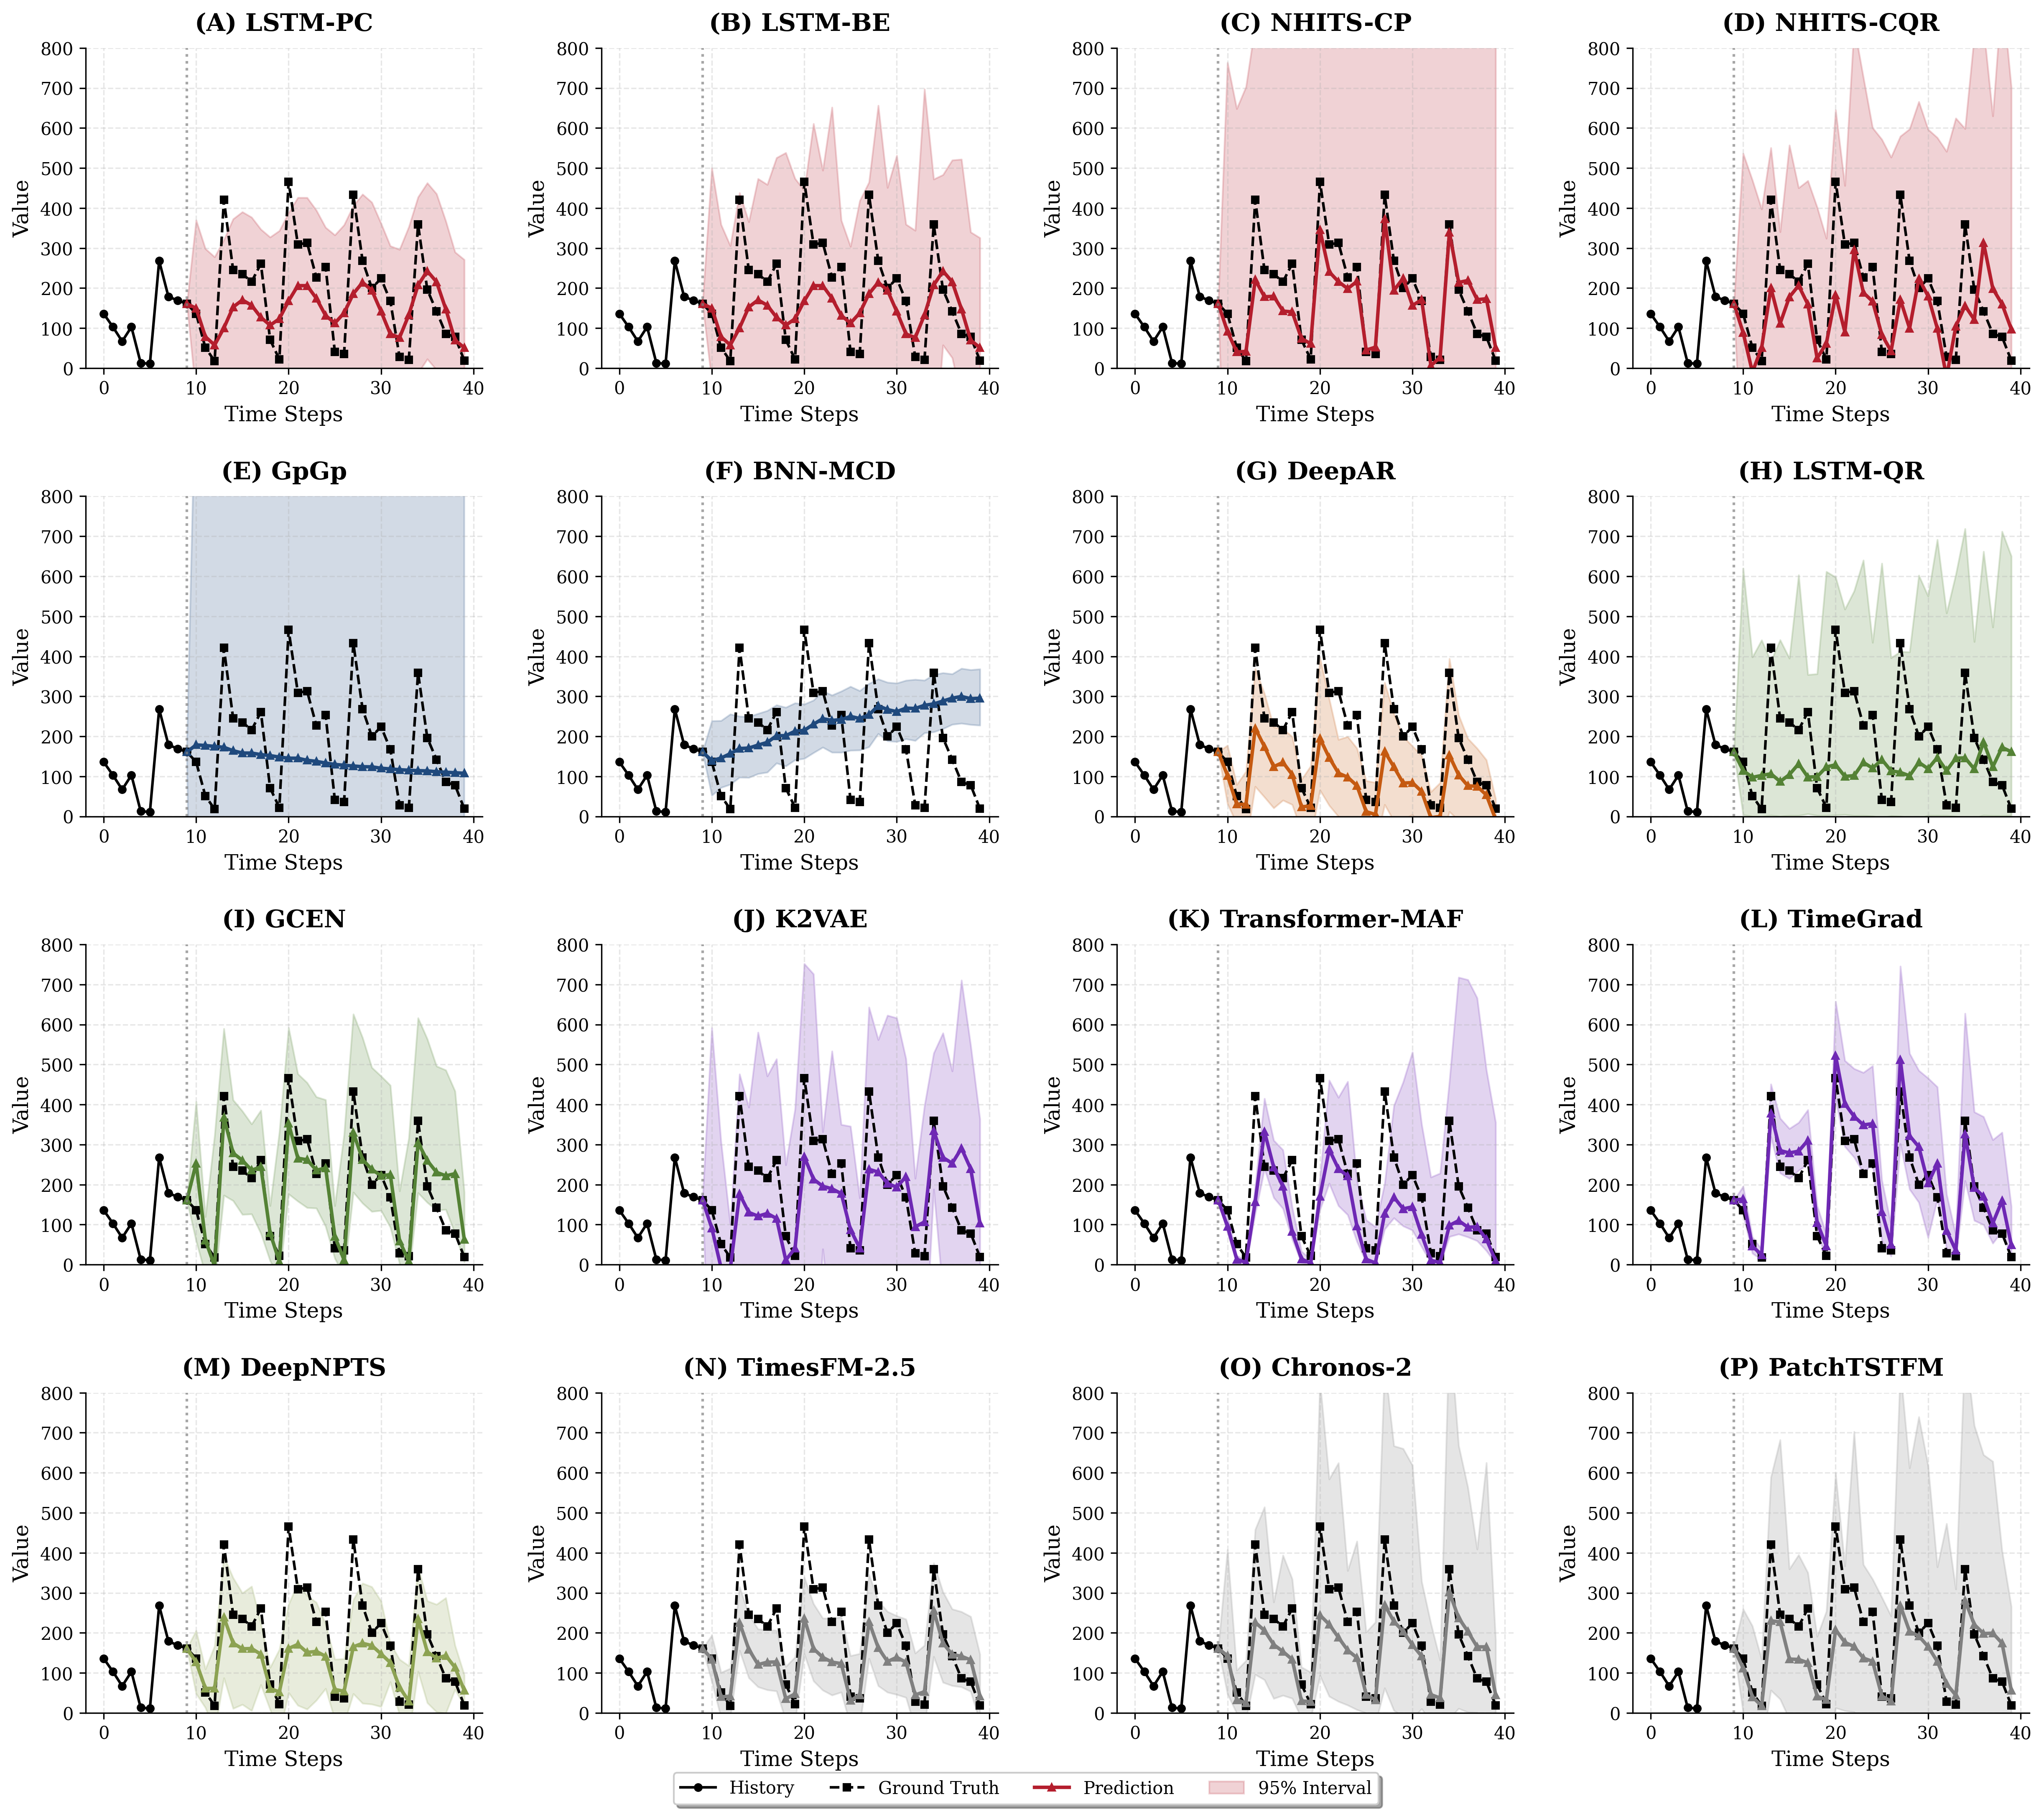

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import string

def rgb_to_hex(rgb):
    """
    Converts an [R, G, B] list to a hex color string.
    Expects values in the range 0-255.
    """
    # Ensure values are within the valid 0-255 range and format as 2-digit hex
    return f"#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}"

agnostic = [180, 30, 45]
bayesian = [31, 73, 125]
parametric = [197, 90, 17]
dist_reg = [84, 130, 53]
generative = [110, 40, 180]
agnostic_color = rgb_to_hex(agnostic)
bayesian_color = rgb_to_hex(bayesian)
parametric_color = rgb_to_hex(parametric)
dist_reg_color = rgb_to_hex(dist_reg)
generative_color = rgb_to_hex(generative)
fm_color = 'grey' # Placeholder color for Foundational Models

# Set the node index from 0 to 10
NODE_IDX = 4
NUM_TRAIN_POINTS = 10

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False
})

models_config = [
    {'title': 'LSTM-PC',               'file': 'Belgium_LSTMPC.npz', 'color': agnostic_color},
    {'title': 'LSTM-BE',        'file': 'Belgium_LSTMBE.npz',  'color': agnostic_color},
    {'title': 'NHITS-CP',                'file': 'Belgium_NHITSCP.npz',  'color': agnostic_color},
    {'title': 'NHITS-CQR',              'file': 'Belgium_CQR.npz',        'color': agnostic_color},
    
    {'title': 'GpGp',                  'file': 'Belgium_GpGp.npz',       'color': bayesian_color},
    {'title': 'BNN-MCD',                 'file': 'Belgium_BNNMCD.npz',        'color': bayesian_color},
    {'title': 'DeepAR',              'file': 'Belgium_DeepAR.npz',      'color': parametric_color},
    {'title': 'LSTM-QR',       'file': 'Belgium_LSTMQR.npz',         'color': dist_reg_color},
    
    {'title': 'GCEN',                'file': 'Belgium_GCEN.npz',       'color': dist_reg_color},
    {'title': 'K2VAE',                      'file': 'Belgium_K2VAE.npz',      'color': generative_color},
    {'title': 'Transformer-MAF', 'file': 'Belgium_TransformerMAF.npz',        'color': generative_color},
    {'title': 'TimeGrad',             'file': 'Belgium_TimeGrad.npz',   'color': generative_color},
    
    {'title': 'DeepNPTS',        'file': 'Belgium_DeepNPTS.npz',   'color': '#8ca252'},
    
    {'title': 'TimesFM-2.5',             'file': 'Belgium_TimesFM.npz',   'color': fm_color},
    {'title': 'Chronos-2',             'file': 'Belgium_Chronos.npz',   'color': fm_color},
    {'title': 'PatchTSTFM',             'file': 'Belgium_PatchTSTFM.npz',   'color': fm_color}
]


# Create figure
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.4, wspace=0.3)

axes = []
# Create axes for the 4 rows (4x4 = 16 plots)
for r in range(4):
    for c in range(4):
        ax = fig.add_subplot(gs[r, c])
        axes.append(ax)

# Generate alphabet labels for titles: (A), (B), (C), ...
alphabet_labels = list(string.ascii_uppercase)

for idx, (config, ax) in enumerate(zip(models_config, axes)):
    
    # Prepend the letter prefix to the title
    plot_title = f"({alphabet_labels[idx]}) {config['title']}"
    
    try:
        # Load data
        data = np.load(config['file'])
        
        # Grab all timesteps for the specific node
        y_train = data['y_train'][:, NODE_IDX]
        y_true  = data['y_true'][:, NODE_IDX]
        y_pred  = data['y_point_pred'][:, NODE_IDX]
        upper   = data['upper_bounds'][:, NODE_IDX]
        lower   = data['lower_bounds'][:, NODE_IDX]
        
        # Grab exactly the last 10 points of the training data
        y_train_last = y_train[-NUM_TRAIN_POINTS:]
        
        # Determine forecast horizon dynamically from the prediction length
        forecast_horizon = len(y_pred)
        
        # Match ground truth length to predictions
        y_true_future = y_true[-forecast_horizon:] if len(y_true) > forecast_horizon else y_true[:forecast_horizon]
        
        # Create continuous time indices for plotting
        t_train = np.arange(NUM_TRAIN_POINTS)
        
        # t_pred goes from index 9 onwards 
        t_pred = np.arange(NUM_TRAIN_POINTS - 1, NUM_TRAIN_POINTS + forecast_horizon)
        
        # Connect the last training point to the predictions to avoid visual gaps
        last_train_val = y_train_last[-1]
        
        plot_y_true = np.insert(y_true_future, 0, last_train_val)
        plot_y_pred = np.insert(y_pred, 0, last_train_val)
        plot_upper  = np.insert(upper, 0, last_train_val)
        plot_lower  = np.insert(lower, 0, last_train_val)

        # Plot Ground Truth (Train + Future)
        ax.plot(t_train, y_train_last, color='black', marker='o', markersize=4, 
                linewidth=1.5, label='History' if idx == 0 else "")
        ax.plot(t_pred, plot_y_true, color='black', linestyle='--', marker='s', 
                markersize=4, linewidth=1.5, label='Ground Truth' if idx == 0 else "")
        
        # Plot Predictions
        ax.plot(t_pred, plot_y_pred, color=config['color'], marker='^', 
                markersize=4, linewidth=2, label='Prediction' if idx == 0 else "")
        
        # Plot 95% Confidence Intervals
        ax.fill_between(t_pred, plot_lower, plot_upper, color=config['color'], 
                        alpha=0.2, label='95% Interval' if idx == 0 else "")
        
        # Title and Labels
        ax.set_title(plot_title, fontweight='bold', pad=10)
        ax.set_xlabel('Time Steps')
        ax.set_ylabel('Value')
        
        # Enforce limits globally
        ax.set_ylim(0, 800)
        
        # A vertical line to denote the start of the forecast period
        ax.axvline(x=NUM_TRAIN_POINTS - 1, color='gray', linestyle=':', alpha=0.7)
        
    except FileNotFoundError:
        ax.text(0.5, 0.5, f"File Not Found:\n{config['file']}", 
                ha='center', va='center', color='red', fontsize=8, wrap=True)
        ax.set_title(plot_title, fontweight='bold')
        ax.set_ylim(0, 800)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error:\n{str(e)}", 
                ha='center', va='center', color='red', fontsize=8, wrap=True)
        ax.set_title(plot_title, fontweight='bold')
        ax.set_ylim(0, 800)

# Add a single master legend to the figure at the top center
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.0), frameon=True, shadow=True)

# Adjust bounds so the legend doesn't overlap the top row
plt.subplots_adjust(top=0.88, bottom=0.05)

# Save and show
plt.savefig('Belgium_Benchmark_Forecasts.pdf', bbox_inches='tight')
plt.show()

# Violin Plot for PICP and Winkler Score

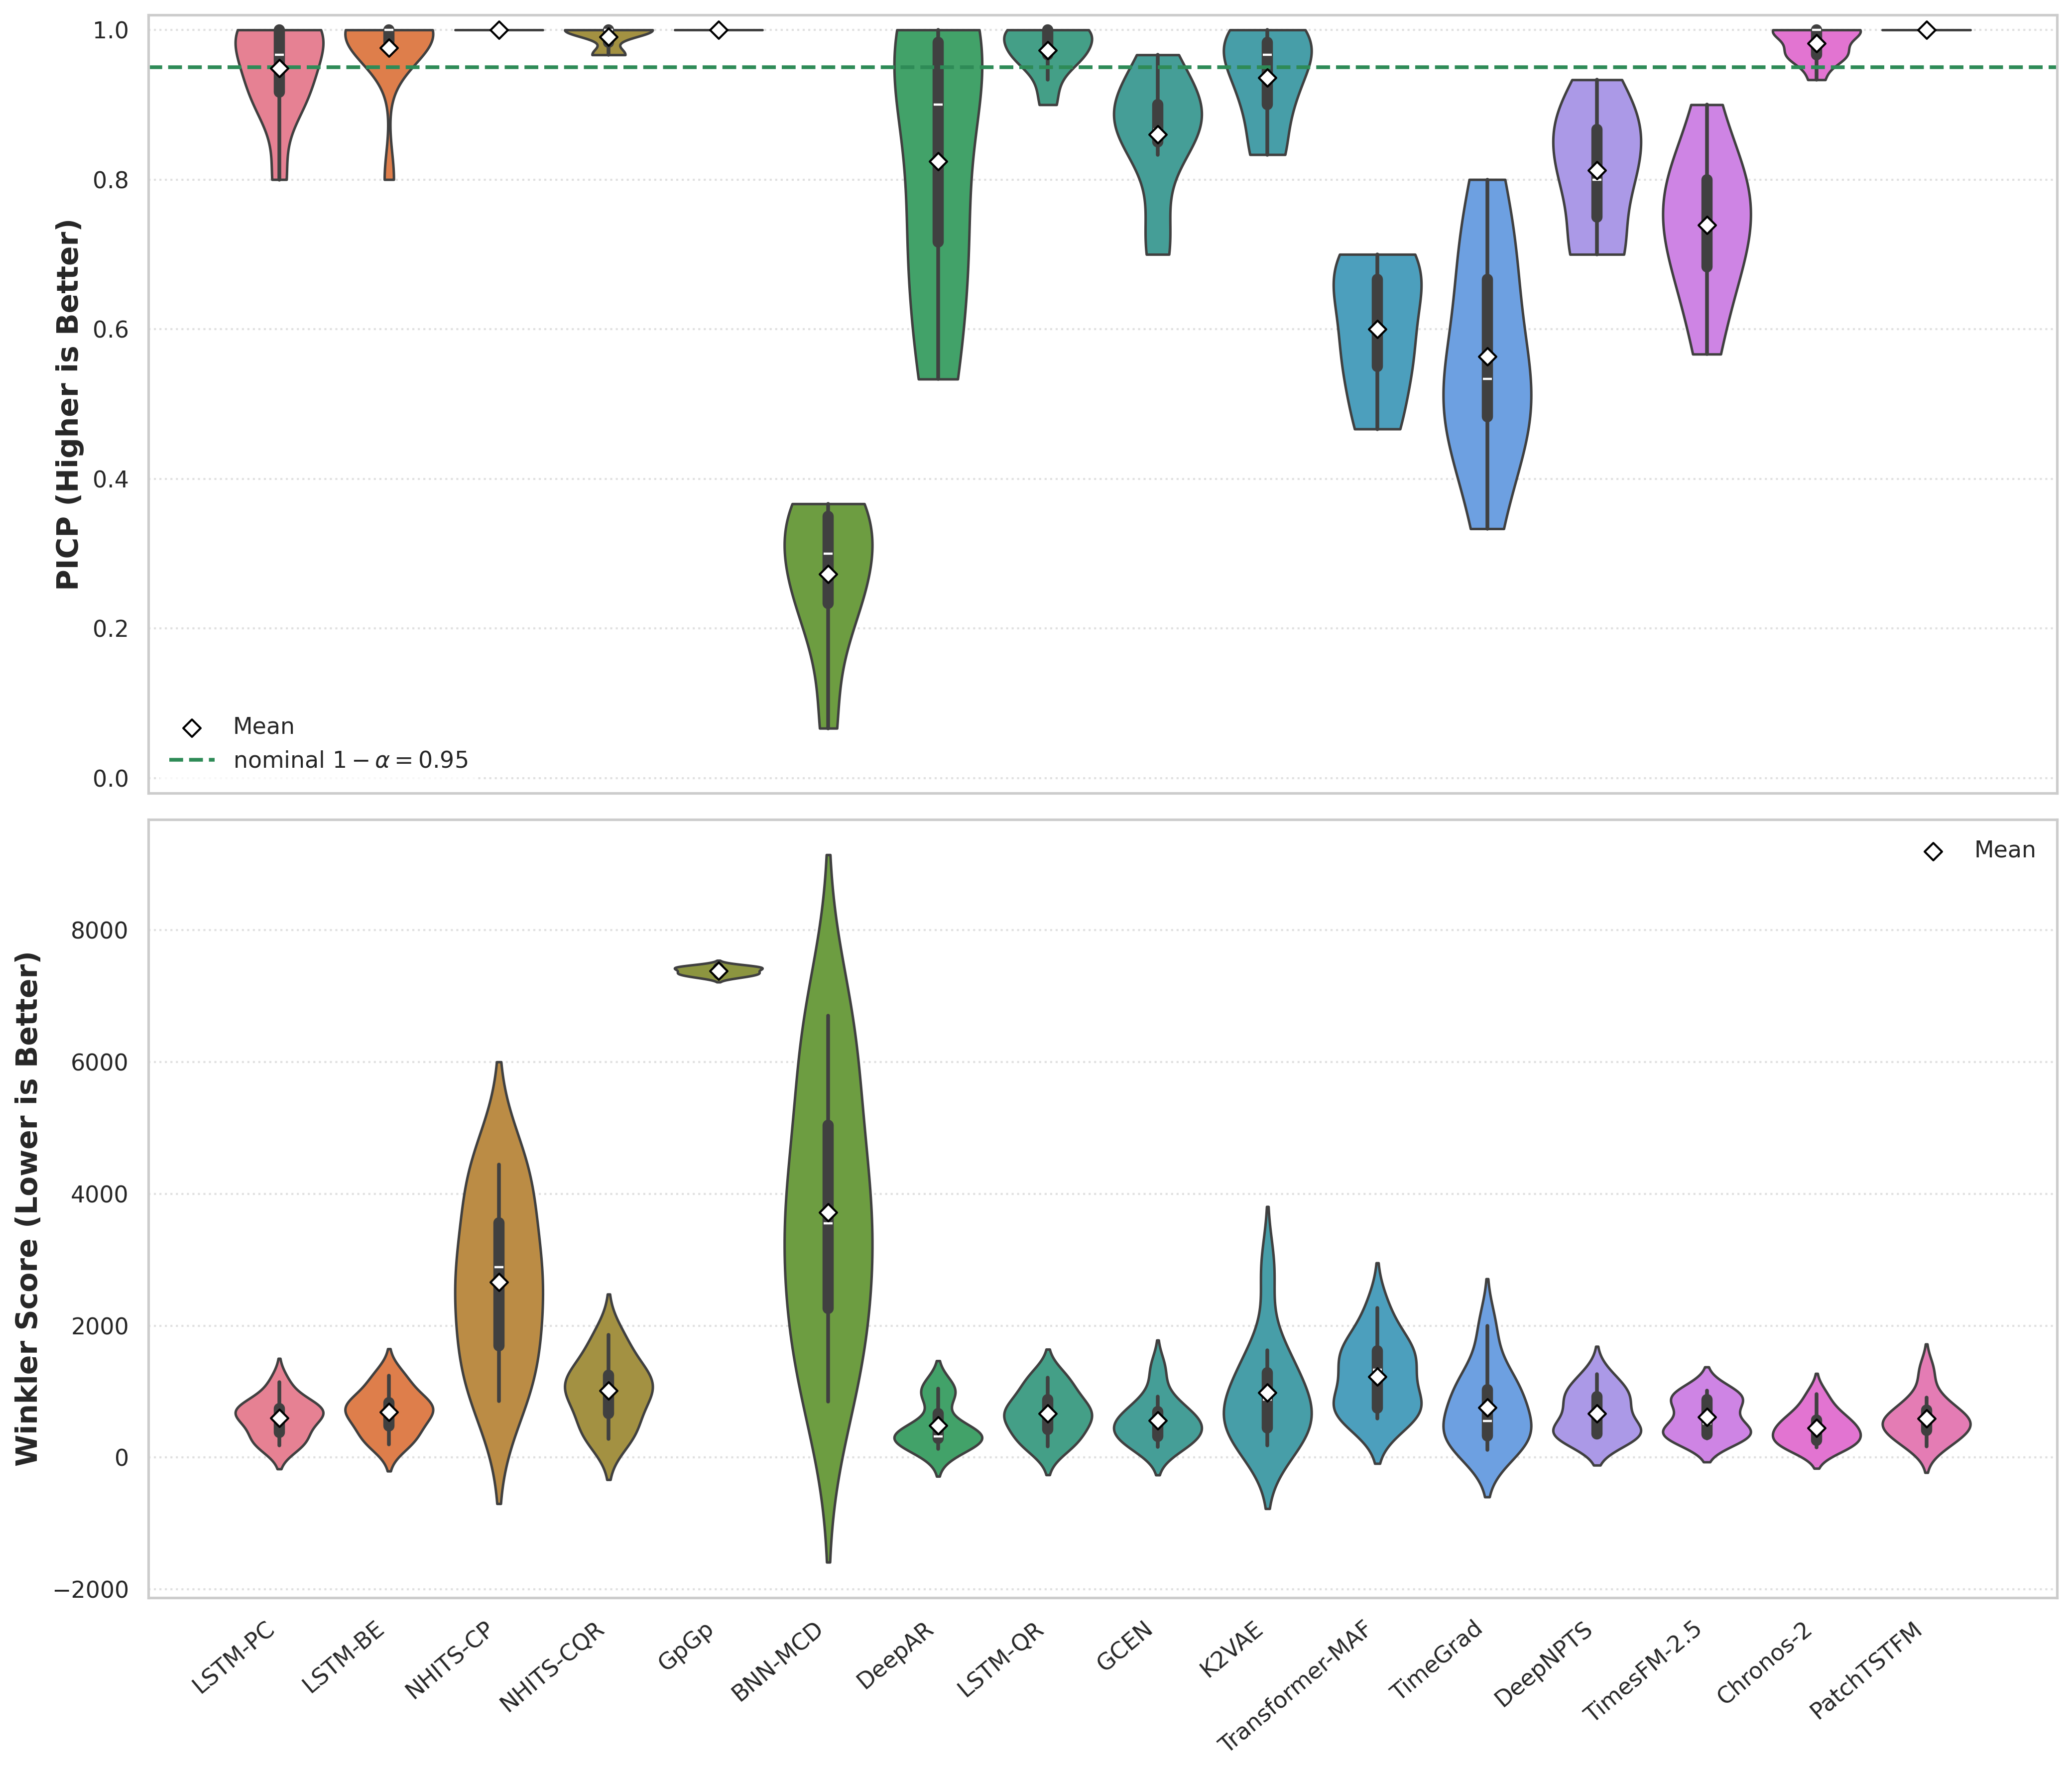

In [5]:
# Violin plot showing PICP and Winkler scores for Belgium COVID-19 dataset across 11 nodes for all models

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def rgb_to_hex(rgb):
    """
    Converts an [R, G, B] list to a hex color string.
    Expects values in the range 0-255.
    """
    # Ensure values are within the valid 0-255 range and format as 2-digit hex
    return f"#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}"

agnostic = [180, 30, 45]
bayesian = [31, 73, 125]
parametric = [197, 90, 17]
dist_reg = [84, 130, 53]
generative = [110, 40, 180]
agnostic_color = rgb_to_hex(agnostic)
bayesian_color = rgb_to_hex(bayesian)
parametric_color = rgb_to_hex(parametric)
dist_reg_color = rgb_to_hex(dist_reg)
generative_color = rgb_to_hex(generative)
fm_color = 'grey' 

models_config = [
    {'title': 'LSTM-PC',               'file': 'Belgium_LSTMPC.npz', 'color': agnostic_color},
    {'title': 'LSTM-BE',        'file': 'Belgium_LSTMBE.npz',  'color': agnostic_color},
    {'title': 'NHITS-CP',                'file': 'Belgium_NHITSCP.npz',  'color': agnostic_color},
    {'title': 'NHITS-CQR',              'file': 'Belgium_CQR.npz',        'color': agnostic_color},
    
    {'title': 'GpGp',                  'file': 'Belgium_GpGp.npz',       'color': bayesian_color},
    {'title': 'BNN-MCD',                 'file': 'Belgium_BNNMCD.npz',        'color': bayesian_color},
    {'title': 'DeepAR',              'file': 'Belgium_DeepAR.npz',      'color': parametric_color},
    {'title': 'LSTM-QR',       'file': 'Belgium_LSTMQR.npz',         'color': dist_reg_color},
    
    {'title': 'GCEN',                'file': 'Belgium_GCEN.npz',       'color': dist_reg_color},
    {'title': 'K2VAE',                      'file': 'Belgium_K2VAE.npz',      'color': generative_color},
    {'title': 'Transformer-MAF', 'file': 'Belgium_TransformerMAF.npz',        'color': generative_color},
    {'title': 'TimeGrad',             'file': 'Belgium_TimeGrad.npz',   'color': generative_color},
    
    {'title': 'DeepNPTS',        'file': 'Belgium_DeepNPTS.npz',   'color': '#8ca252'},
    
    {'title': 'TimesFM-2.5',             'file': 'Belgium_TimesFM.npz',   'color': fm_color},
    {'title': 'Chronos-2',             'file': 'Belgium_Chronos.npz',   'color': fm_color},
    {'title': 'PatchTSTFM',             'file': 'Belgium_PatchTSTFM.npz',   'color': fm_color}
]

def compute_node_metrics(y_true, lower_bounds, upper_bounds, alpha=0.05):
    """
    Computes Empirical Coverage and Winkler Score per node by averaging over the horizon.
    """
    # Empirical Coverage
    covered = (y_true >= lower_bounds) & (y_true <= upper_bounds)
    coverage_per_node = np.mean(covered, axis=0)
    
    # Winkler Score (Single 95% Layer)
    interval_width = upper_bounds - lower_bounds
    penalty_lower = (2.0 / alpha) * (lower_bounds - y_true) * (y_true < lower_bounds)
    penalty_upper = (2.0 / alpha) * (y_true - upper_bounds) * (y_true > upper_bounds)
    
    winkler_full = interval_width + penalty_lower + penalty_upper
    winkler_per_node = np.mean(winkler_full, axis=0)
    
    return coverage_per_node, winkler_per_node

coverage_records = []
winkler_records = []

for model_cfg in models_config:
    title = model_cfg['title']
    file_path = model_cfg['file']
    
    if not os.path.exists(file_path):
        print(f"Warning: File not found - {file_path}. Skipping...")
        continue
        
    data = np.load(file_path)
    
    y_true = data['y_true']
    lower_bounds = data['lower_bounds']
    upper_bounds = data['upper_bounds']
    
    # Compute metrics averaged across horizon
    cov_nodes, wink_nodes = compute_node_metrics(y_true, lower_bounds, upper_bounds, alpha=0.05)
    
    for cov_val in cov_nodes:
        coverage_records.append({'Model': title, 'Empirical Coverage': cov_val})
        
    for wink_val in wink_nodes:
        winkler_records.append({'Model': title, 'Winkler Score': wink_val})

df_coverage = pd.DataFrame(coverage_records)
df_winkler = pd.DataFrame(winkler_records)

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# Create a 2x1 figure layout, sharing the X-axis
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12), sharex=True)

# Generate a distinct color palette for the exact number of models
unique_models = df_coverage['Model'].unique()
palette = sns.color_palette("husl", len(unique_models))

# Top Plot: PICP
sns.violinplot(
    data=df_coverage,
    x='Model',
    y='Empirical Coverage',
    palette=palette,
    inner='box',
    cut=0,
    scale='width',
    linewidth=1.2,
    ax=axes[0]
)

# Overlay Mean Diamonds
means_cov = df_coverage.groupby('Model', sort=False)['Empirical Coverage'].mean()
x_coords = np.arange(len(means_cov))
axes[0].scatter(x_coords, means_cov, color='white', marker='D', s=35, edgecolor='black', zorder=5, label='Mean')

# Target nominal line (95%)
axes[0].axhline(y=0.95, color='seagreen', linestyle='--', linewidth=1.8, label=r'nominal $1 - \alpha = 0.95$')

axes[0].set_ylim(-0.02, 1.02)
axes[0].set_ylabel('PICP (Higher is Better)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('') # Hide x-label for top plot
axes[0].yaxis.grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none')

# Bottom Plot: Winkler Score
sns.violinplot(
    data=df_winkler,
    x='Model',
    y='Winkler Score',
    palette=palette,
    inner='box',
    scale='width',
    linewidth=1.2,
    ax=axes[1]
)

# Overlay Mean Diamonds
means_wink = df_winkler.groupby('Model', sort=False)['Winkler Score'].mean()
axes[1].scatter(x_coords, means_wink, color='white', marker='D', s=35, edgecolor='black', zorder=5, label='Mean')

axes[1].set_ylabel('Winkler Score (Lower is Better)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].yaxis.grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

# Format x-axis ticks on the bottom plot only
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha='right', fontsize=11)

# Final Layout Adjustments
plt.tight_layout()
plt.savefig('Belgium_Violin_Plot.pdf', format='pdf')
plt.show()

# Training and Inference Times on Belgium COVID-19 Data

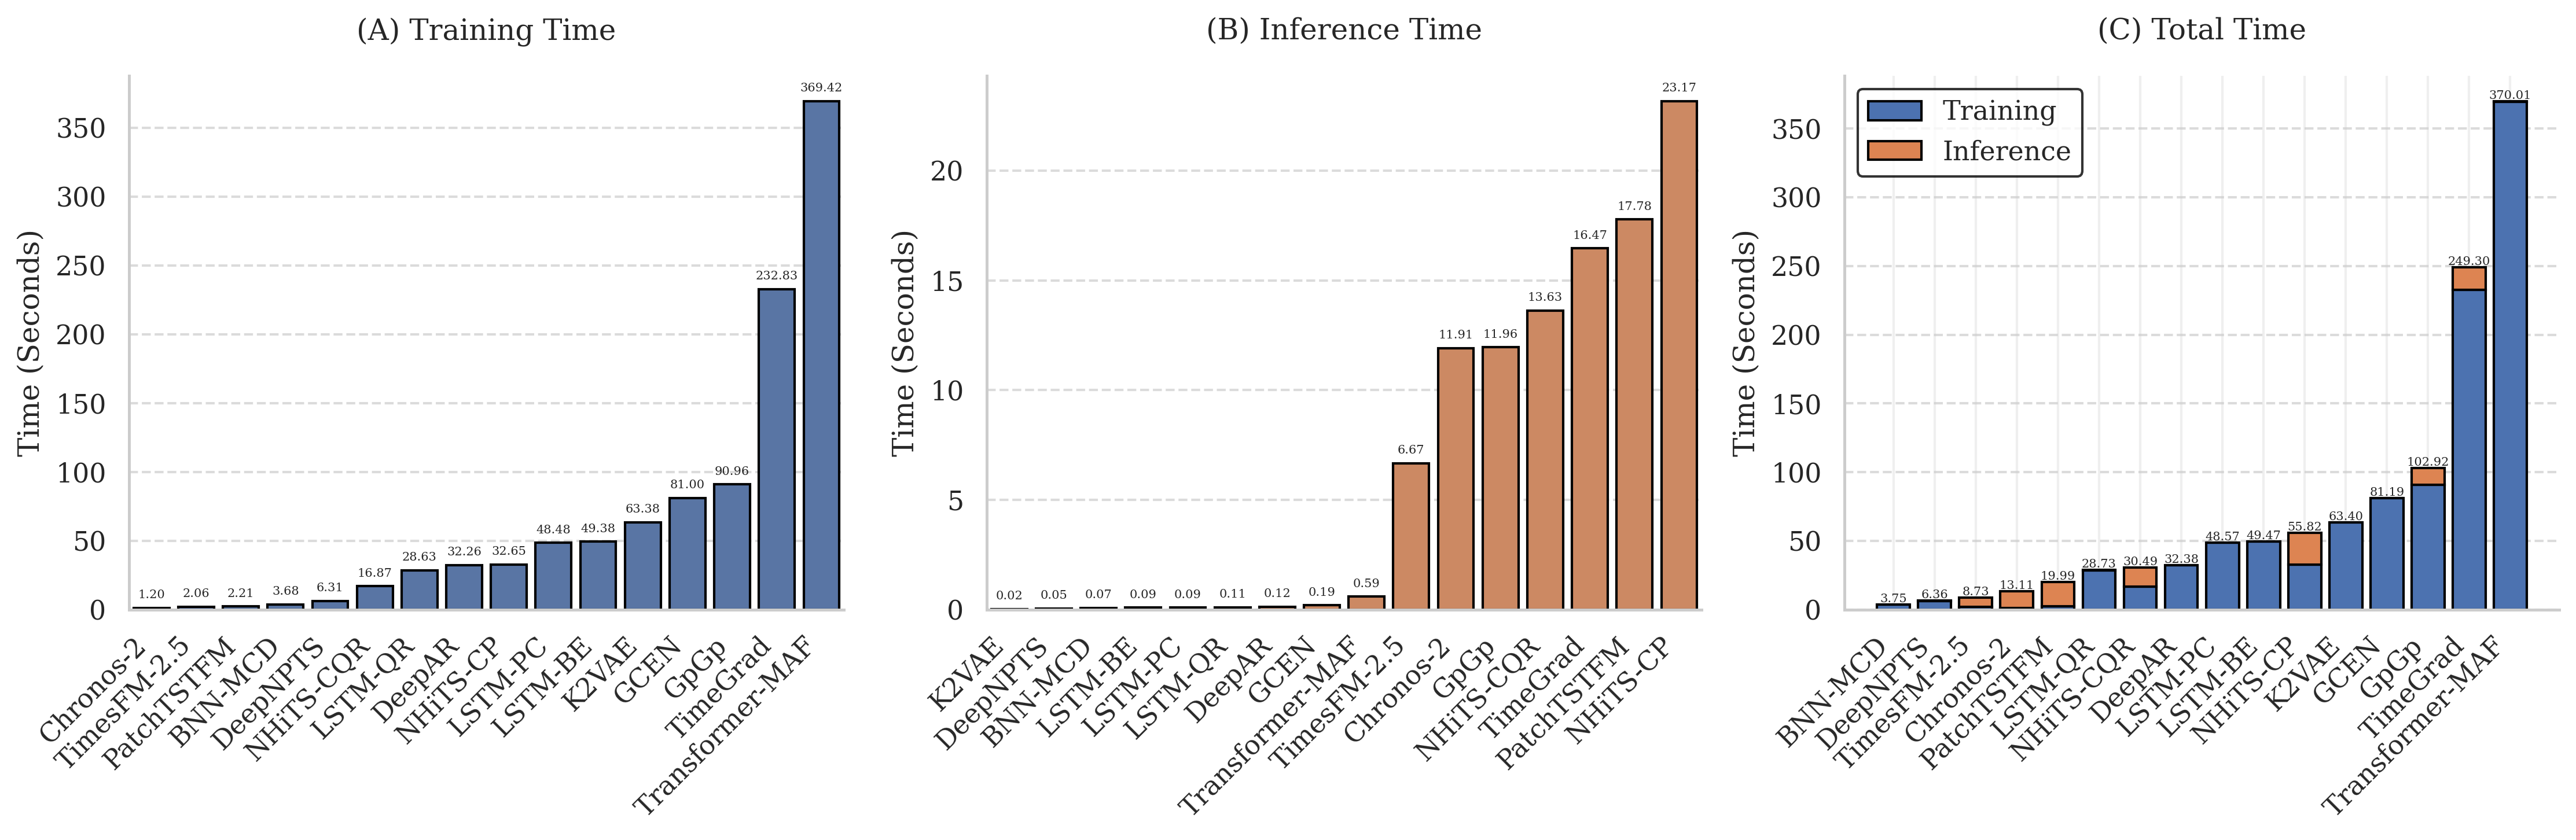

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 12,
    "font.size": 12,
    "figure.dpi": 300,
    "axes.linewidth": 1.2
})

# Load and transpose the data
df = pd.read_csv('Benchmark_Times.csv', index_col=0)
df_models = df.T  # Models become the index

# Calculate the Total time
df_models['Total'] = df_models['Training'] + df_models['Inference']

# Sort data independently for each subplot
df_train_sorted = df_models.sort_values(by='Training')
df_infer_sorted = df_models.sort_values(by='Inference')
df_total_sorted = df_models.sort_values(by='Total')

# Create a 1x3 subplot figure 
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Training Times 
sns.barplot(
    x=df_train_sorted.index, 
    y=df_train_sorted['Training'], 
    ax=ax1, 
    color='#4C72B0', 
    edgecolor='black'
)
ax1.set_title('(A) Training Time', pad=15)
ax1.set_ylabel('Time (Seconds)')
ax1.set_xlabel('')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=3, fontsize=5)

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


# Plot 2: Inference Times 
sns.barplot(
    x=df_infer_sorted.index, 
    y=df_infer_sorted['Inference'], 
    ax=ax2, 
    color='#DD8452', 
    edgecolor='black'
)
ax2.set_title('(B) Inference Time', pad=15)
ax2.set_ylabel('Time (Seconds)')
ax2.set_xlabel('')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', padding=3, fontsize=5)

ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


# Plot 3: Stacked Total Time
# Bottom layer: Training
ax3.bar(
    df_total_sorted.index, 
    df_total_sorted['Training'], 
    color='#4C72B0', 
    edgecolor='black',
    label='Training'
)
# Top layer: Inference (stacked on top of Training)
ax3.bar(
    df_total_sorted.index, 
    df_total_sorted['Inference'], 
    bottom=df_total_sorted['Training'], 
    color='#DD8452', 
    edgecolor='black',
    label='Inference'
)

ax3.set_title('(C) Total Time', pad=15)
ax3.set_ylabel('Time (Seconds)')
ax3.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of the stacked bars for the Total Time
for i, total_val in enumerate(df_total_sorted['Total']):
    ax3.text(
        i, total_val, f"{total_val:.2f}", 
        ha='center', va='bottom', fontsize=5
    )

# Formatting the X-axis for the stacked plot
ax3.set_xticks(range(len(df_total_sorted.index)))
ax3.set_xticklabels(df_total_sorted.index, rotation=45, ha='right')

# Add legend to distinguish layers
ax3.legend(frameon=True, edgecolor='black')

sns.despine(fig)
plt.tight_layout()

# Save 
plt.savefig('Training_Inference_Times.pdf', format='pdf', bbox_inches='tight')
plt.show()